In [5]:
import pandas as pd
import numpy as np
import seaborn as sns
import streamlit as st
import sys
import plotly.express as px
from pyvis.network import Network

# Print the path to ensure we are suing the .venv Python
print(f"Python path: {sys.executable}")
print("All libraries imported successfully!")

Python path: c:\Users\PRIYA G\OneDrive\Desktop\Internship_Project_01\.venv\Scripts\python.exe
All libraries imported successfully!


In [ ]:
import pandas as pd
df = pd.read_csv('data/artist_level.csv', encoding='latin1')

In [7]:
df.head()

,date,position,song,popularity,duration_ms,album_type,total_tracks,is_explicit,album_cover_url,artist_name
0,18-05-2024,1,Tattoo,89,183374,single,1,False,https://i.scdn.co/image/ab67616d0000b2732b0ba8...,loreen
1,18-05-2024,2,Daylight,96,212953,single,1,False,https://i.scdn.co/image/ab67616d0000b27395ca6a...,david kushner
2,18-05-2024,3,Cha Cha Cha,86,175161,single,1,False,https://i.scdn.co/image/ab67616d0000b273e9973a...,kã¤ã¤rijã¤
3,18-05-2024,4,Miracle (with Ellie Goulding),91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...,calvin harris
4,18-05-2024,4,Miracle (with Ellie Goulding),91,186496,single,1,False,https://i.scdn.co/image/ab67616d0000b273c58e22...,ellie goulding


In [ ]:
# Clean-up
df['artist_name'] = df['artist_name'].str.strip()
print(df['artist_name'])

0                   loreen
1            david kushner
2               kã¤ã¤rijã¤
3            calvin harris
4           ellie goulding
               ...        
34870        ariana grande
34871          myles smith
34872            vance joy
34873    sabrina carpenter
34874                dasha
Name: artist_name, Length: 34875, dtype: str


In [ ]:
# Count Unique Artist Per Day
daily_unique_artist = df.groupby('date')['artist_name'].nunique()
print(daily_unique_artist)

date
01-01-2025    51
01-02-2025    58
01-03-2025    50
01-04-2025    41
01-05-2025    35
              ..
31-08-2024    62
31-08-2025    35
31-10-2024    32
31-10-2025    36
31-12-2024    53
Name: artist_name, Length: 555, dtype: int64


In [25]:
import matplotlib.pyplot as plt
import seaborn as sns

# 1. Set the Date column as the Index
df_indexed = df.set_index('date')

# 2. Now perform your operation (resampling or rolling)
# Resampling to Weekly (W)
weekly_data = df_indexed['artist_name'].resample('W').nunique()

# 3. OR a 30-day Rolling Average
rolling_avg = df_indexed['artist_name'].resample('D').nunique().rolling(window=30).mean()

# Plotting the Daily Unique Artist Count
plt.figure(figsize=(10,6))
weekly_data.plot(kind='line', marker='o', color='teal' )

plt.title('Unique Artist Per Day on UK Top 50')
plt.xlabel('Date')
plt.ylabel('Number of Unique Artist')
plt.grid(True)
plt.show()

TypeError: Only valid with DatetimeIndex, TimedeltaIndex or PeriodIndex, but got an instance of 'Index'

In [ ]:
# Measure total appearance per artist
artist_count = df['artist_name'].value_counts()
print(artist_count)

artist_name
taylor swift                  2091
sabrina carpenter              964
billie eilish                  887
olivia rodrigo                 693
chappell roan                  634
                              ... 
rick james                       1
the adventures of stevie v       1
stromae                          1
pomme                            1
arcane                           1
Name: count, Length: 360, dtype: int64


In [17]:
# Compute the HHI
hhi = ((artist_count / len(df))**2).sum()
print(hhi)

0.011514449403270769


In [18]:
# Equivalent Artist
equivalent_artist = 1/hhi
print(f"Equivalent number of artist: {equivalent_artist:.2f}")

Equivalent number of artist: 86.85


In [4]:
# Identify Top Dominating Artists
artist_count = df['artist_name'].value_counts().reset_index()
print(artist_count.head(50))

            artist_name  count
0          taylor swift   2091
1     sabrina carpenter    964
2         billie eilish    887
3        olivia rodrigo    693
4         chappell roan    634
5          benson boone    537
6           central cee    532
7                 drake    516
8           the killers    511
9              dua lipa    484
10                chase    482
11               status    482
12           noah kahan    458
13                 raye    442
14          teddy swims    433
15       arctic monkeys    432
16           the weeknd    419
17       d-block europe    409
18           tate mcrae    405
19                 dave    397
20           charli xcx    374
21        ariana grande    367
22               cassã¶    348
23         harry styles    333
24               hozier    333
25  natasha bedingfield    319
26            vance joy    314
27           lord huron    293
28          post malone    285
29       ella henderson    278
30      michael marcagi    277
31      

In [ ]:
#  Identify solo vs collaborative tracks
import pandas as pd

# 1. Ensure the column is treated as a string
# We assume standard separators like commas (',') or '&'
df['artist_name'] = df['artist_name'].astype(str)

# 2. Flag as collaboration if it contains a separator
# Adjust the separator list (',', '&', 'feat') based on your data's specific formatting
separators = [',', '&', 'feat', 'ft.']
df['is_collaboration'] = df['artist_name'].str.contains('|'.join(separators), case=False, na=False)

# 3. Categorize
df['track_type'] = df['is_collaboration'].map({True: 'Collaboration', False: 'Solo'})

# 4. View results
print(df['track_type'].value_counts())

track_type
Solo             34638
Collaboration      237
Name: count, dtype: int64


In [30]:
# Average collaborators per song
import pandas as pd

# Define your separator(s). If it's just a comma:
# We count the number of commas and add 1 to get the number of artists.
# Note: Handle cases where the cell might be empty or a single name.
df['num_artists'] = df['artist_name'].str.count(',') + 1

# If you use multiple separators (e.g., "&", "ft."), use a regex pattern:
# This counts occurrences of any of these characters:
df['num_artists'] = df['artist_name'].str.count(r',|&|feat|ft\.') + 1

# Calculate the mean
average_collaborators = df['num_artists'].mean()

print(f"Average number of artists per song: {average_collaborators:.2f}")

Average number of artists per song: 1.01


In [32]:
# Group by the 'album_or_single' column
avg_by_type = df.groupby('album_type')['num_artists'].mean()

print(avg_by_type)

album_type
album          1.010425
compilation    1.000000
single         1.000860
Name: num_artists, dtype: float64


In [58]:
import pandas as pd

# Define the boundaries and labels for your brackets
# Bins: 1-10, 11-50, and 51+ (Assuming your ranking starts at 1)
bins = [0, 10, 50, float('inf')]
labels = ['Top 10', 'Top 50', 'Rest']

df['rank_group'] = pd.cut(df['position'], bins=bins, labels=labels)

# Assuming you have the 'num_artists' column from previous steps
# Calculate mean collaborators per rank group
collab_by_rank = df.groupby('rank_group')['num_artists'].mean()

# Alternatively, see the percentage of collaborative tracks per group
# (Using the 'is_collaboration' boolean column we defined earlier)
collab_percentage = df.groupby('rank_group')['is_collaboration'].mean() * 100

print(collab_by_rank)
print(collab_percentage)

rank_group
Top 10    1.001890
Top 50    1.006537
Name: num_artists, dtype: float64
rank_group
Top 10    0.188981
Top 50    0.800114
Name: is_collaboration, dtype: float64


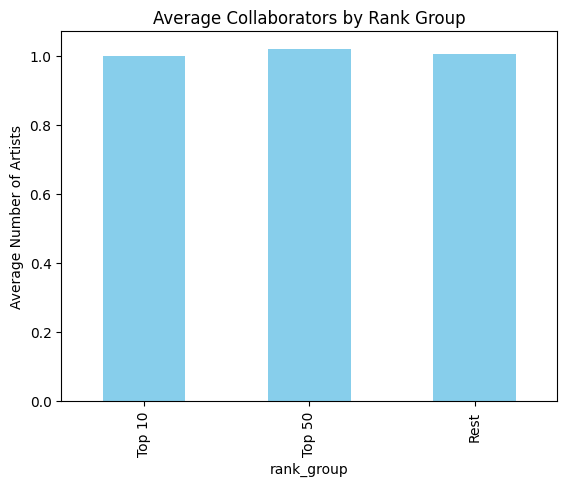

In [35]:
import matplotlib.pyplot as plt

collab_by_rank.plot(kind='bar', color='skyblue')
plt.title('Average Collaborators by Rank Group')
plt.ylabel('Average Number of Artists')
plt.show()

In [37]:
import pandas as pd
import itertools

# 1. Clean and split the artist column into lists
# Assuming artists are separated by commas (',')
df['artist_list'] = df['artist_name'].str.split(',').apply(lambda x: [a.strip() for a in x])

# 2. Create an edge list
# For each song, find all unique pairs of artists
edges = []
for artists in df['artist_list']:
    if len(artists) > 1:
        # itertools.combinations creates every possible pair in a list
        edges.extend(list(itertools.combinations(sorted(artists), 2)))

# 3. Create a DataFrame of edges
edge_df = pd.DataFrame(edges, columns=['source', 'target'])

# 4. Count the frequency of each collaboration (for edge weight)
edge_df = edge_df.groupby(['source', 'target']).size().reset_index(name='weight')

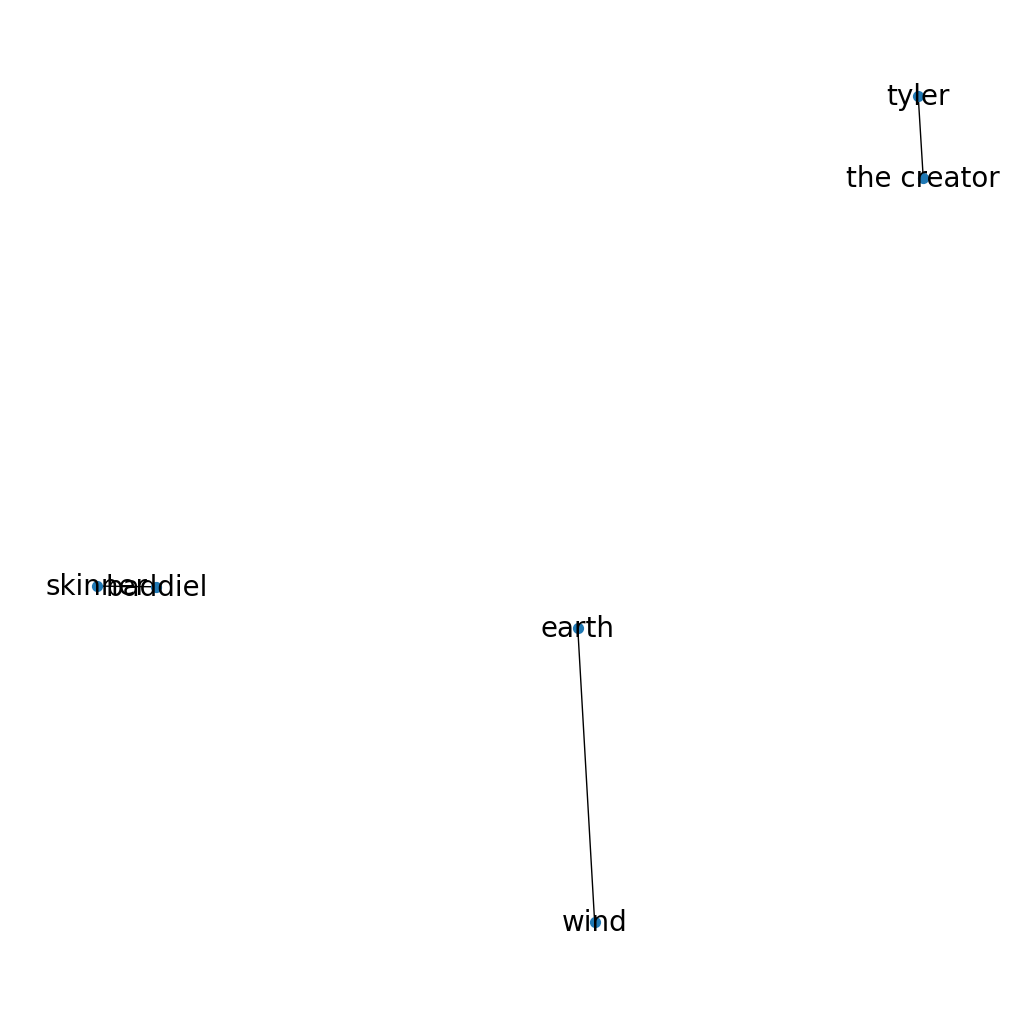

In [40]:
import networkx as nx
import matplotlib.pyplot as plt

# Create graph from edge list
G = nx.from_pandas_edgelist(edge_df, 'source', 'target', ['weight'])

# Basic visualization (for small datasets)
plt.figure(figsize=(10, 10))
pos = nx.spring_layout(G)
nx.draw(G, pos, with_labels=True, node_size=50, font_size=20)
plt.show()

In [41]:
import pandas as pd

# 1. Normalize the explicitness column (assuming column name is 'explicit')
# If it is boolean, this part is already done.
# If it is strings, map them to a boolean or standard categories:
df['is_explicit'] = df['is_explicit'].replace({
    'Explicit': True, 
    'Clean': False, 
    'Non-explicit': False
}).astype(bool)

# 2. Get the counts
explicitness_counts = df['is_explicit'].value_counts()
print(explicitness_counts)

is_explicit
False    22916
True     11959
Name: count, dtype: int64


In [57]:
# Assuming you already created 'rank_group'
explicit_by_rank = df.groupby('position')['is_explicit'].mean() * 100
print(explicit_by_rank)

position
1     55.341246
2     39.674797
3     37.254902
4     45.693431
5     51.282051
6     47.291362
7     47.510669
8     45.980254
9     46.857923
10    46.896552
11    42.404227
12    41.121495
13    41.997439
14    33.741497
15    31.818182
16    34.008097
17    38.561151
18    28.673324
19    33.619456
20    35.187761
21    34.423898
22    33.475177
23    34.861111
24    32.248939
25    34.078212
26    32.644628
27    29.971989
28    31.276901
29    31.420373
30    32.467532
31    30.801688
32    31.034483
33    26.686657
34    27.326440
35    31.130690
36    25.341426
37    26.734104
38    29.411765
39    29.498525
40    28.913963
41    29.733520
42    28.718704
43    29.331307
44    23.042169
45    28.276878
46    24.328147
47    23.318386
48    29.855072
49    27.868852
50    26.008969
Name: is_explicit, dtype: float64


In [43]:
# Using the 'track_type' column you created earlier
explicit_by_type = df.groupby('track_type')['is_explicit'].mean() * 100
print(explicit_by_type)

track_type
Collaboration    76.793249
Solo             34.000231
Name: is_explicit, dtype: float64


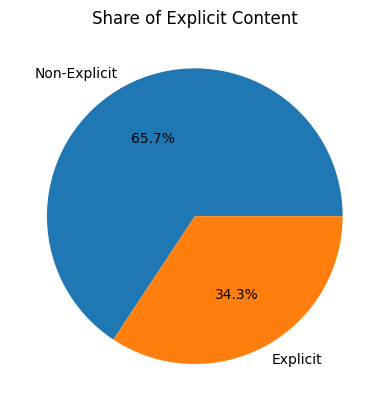

In [44]:
import matplotlib.pyplot as plt

# Simple Pie Chart
explicitness_counts.plot(kind='pie', autopct='%1.1f%%', labels=['Non-Explicit', 'Explicit'])
plt.title('Share of Explicit Content')
plt.show()

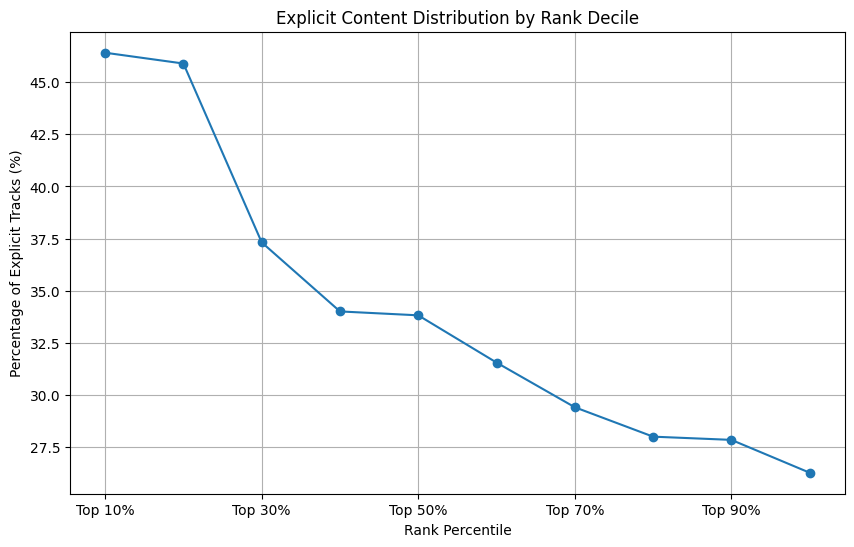

In [56]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Ensure rank is numeric and remove any missing values
df = df.dropna(subset=['position'])

# 2. Create 10 equal-sized bins based on rank (1st Decile = Top 10%, 10th Decile = Bottom 10%)
df['rank_decile'] = pd.qcut(df['position'], q=10, labels=[f'Top {i*10}%' for i in range(1, 11)])

# 3. Calculate the percentage of explicit content per decile
explicit_dist = df.groupby('rank_decile')['is_explicit'].mean() * 100

# 4. Plot the trend
explicit_dist.plot(kind='line', marker='o', figsize=(10, 6))
plt.title('Explicit Content Distribution by Rank Decile')
plt.ylabel('Percentage of Explicit Tracks (%)')
plt.xlabel('Rank Percentile')
plt.grid(True)
plt.show()

album_type      album  compilation     single
position                                     
1           35.756677     0.148368  64.094955
2           31.219512          NaN  68.780488
3           42.647059          NaN  57.352941
4           30.802920          NaN  69.197080
5           35.357625     0.134953  64.507422
6           43.777452          NaN  56.222548
7           44.807966     0.142248  55.049787
8           40.620592          NaN  59.379408
9           40.300546          NaN  59.699454
10          38.068966          NaN  61.931034
11          42.668428          NaN  57.331572
12          44.993324          NaN  55.006676
13          39.564661     0.512164  59.923175
14          42.721088     0.408163  56.870748
15          45.312500     0.994318  53.693182
16          40.755735     1.619433  57.624831
17          47.050360     1.438849  51.510791
18          42.510699     1.426534  56.062767
19          49.213162     1.001431  49.785408
20          42.976356          NaN

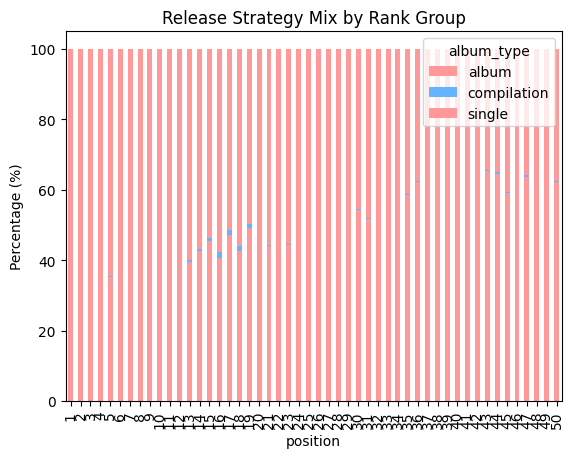

In [55]:
import pandas as pd
import matplotlib.pyplot as plt

# 1. Compare the count of singles vs album tracks in the Top 10/Top 50
strategy_dist = df.groupby(['position', 'album_type']).size().unstack()

# 2. Convert to percentages to see the "Strategy Mix"
strategy_pct = strategy_dist.div(strategy_dist.sum(axis=1), axis=0) * 100

print(strategy_pct)

# 3. Visualize
strategy_pct.plot(kind='bar', stacked=True, color=['#ff9999','#66b3ff'])
plt.title('Release Strategy Mix by Rank Group')
plt.ylabel('Percentage (%)')
plt.show()

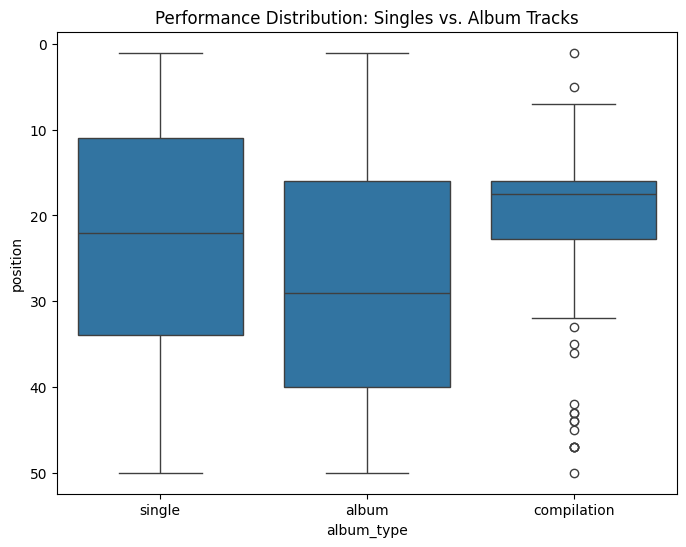

In [54]:
import seaborn as sns

plt.figure(figsize=(8, 6))
sns.boxplot(x='album_type', y='position', data=df)
plt.title('Performance Distribution: Singles vs. Album Tracks')
plt.gca().invert_yaxis() # Invert so Rank 1 is at the top
plt.show()

In [51]:
# Group by artist and release type
artist_strategy = df.groupby(['artist_name', 'album_type']).size().unstack(fill_value=0)

# Calculate the ratio: How much of the artist's discography is from singles?
artist_strategy['single_focus'] = artist_strategy['single'] / (artist_strategy['single'] + artist_strategy['album'])

print(artist_strategy.sort_values('single_focus', ascending=False).head(10))

album_type     album  compilation  single  single_focus
artist_name                                            
trippie redd       0            0      30           1.0
tommy richman      0            0     160           1.0
tiakola            0            0       1           1.0
band aid           0            0      33           1.0
badger             0            0      72           1.0
bad bunny          0            0      15           1.0
babytron           0            0       6           1.0
baby lasagna       0            0       3           1.0
ava max            0            0      74           1.0
atomic kitten      0            0       2           1.0


In [59]:
# Generate a unique ID by combining song, artist, and date
df['track_id'] = df['song'] + "_" + df['artist_name'] + "_" + df['date']

In [5]:
import pandas as pd

# 1. Create your dataset
data = {
    'artist_name': ['taylor swift', 'sabrina carpenter', 'billie eilish', 'olivia rodrigo', 'chappell roan', 'benson boone', 'central cee', 'drake', 'the killers', 'dua lipa', 'chase', 'status', 'noah kahan', 'raye', 'teddy swims', 'arctic monkeys', 'the weeknd', 'd-block europe', 'tate mcrae', 'dave', 'charli xcx', 'ariana grande', 'cassö', 'harry styles', 'hozier', 'natasha bedingfield', 'vance joy', 'lord huron', 'post malone', 'ella henderson', 'michael marcagi', 'sza', 'doja cat', 'dasha', 'ice spice', 'jazzy', 'kanye west', 'david guetta', 'coldplay', 'david kushner', 'beyoncé', 'clementine douglas', 'tyla', 'shaboozey', 'fred again..', 'myles smith', 'madonna', 'bou', 'kendrick lamar', 'kenya grace'],
    'count': [2091, 964, 887, 693, 634, 537, 532, 516, 511, 484, 482, 482, 458, 442, 433, 432, 419, 409, 405, 397, 374, 367, 348, 333, 333, 319, 314, 293, 285, 278, 277, 267, 261, 255, 242, 242, 240, 236, 236, 234, 231, 218, 218, 218, 217, 212, 208, 208, 207, 207]
}

df = pd.DataFrame(data)

# 2. Calculate HHI
total_counts = df['count'].sum()
df['share'] = df['count'] / total_counts
hhi = (df['share']**2).sum()
print(f"HHI Score: {hhi:.4f}")

# 3. Calculate Localization (Simplified Example)
uk_artists = ['central cee', 'chase', 'status', 'raye', 'arctic monkeys', 'd-block europe', 'dave', 'charli xcx', 'cassö', 'natasha bedingfield', 'ella henderson', 'jazzy', 'clementine douglas', 'fred again..', 'myles smith', 'bou', 'kenya grace', 'coldplay']
df['origin'] = df['artist_name'].apply(lambda x: 'UK' if x in uk_artists else 'International')

localization = df.groupby('origin')['count'].sum() / total_counts
print("\nMarket Share by Origin:")
print(localization)

HHI Score: 0.0306

Market Share by Origin:
origin
International    0.699542
UK               0.300458
Name: count, dtype: float64


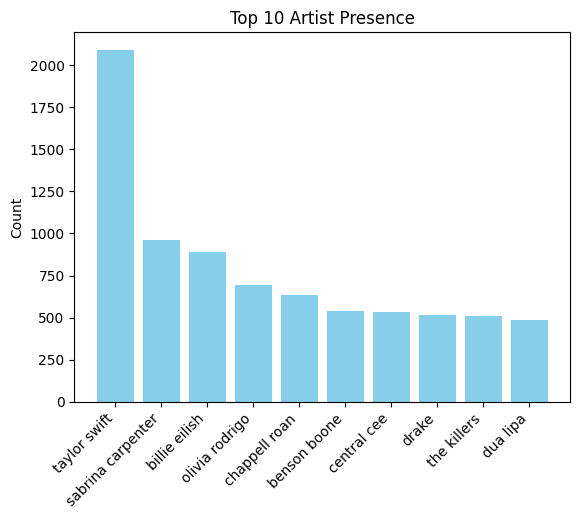

In [6]:
import matplotlib.pyplot as plt

# Create a bar chart of the top 10 artists for visual impact
top_10 = df.head(10)
plt.bar(top_10['artist_name'], top_10['count'], color='skyblue')
plt.xticks(rotation=45, ha='right')
plt.title('Top 10 Artist Presence')
plt.ylabel('Count')
plt.show()

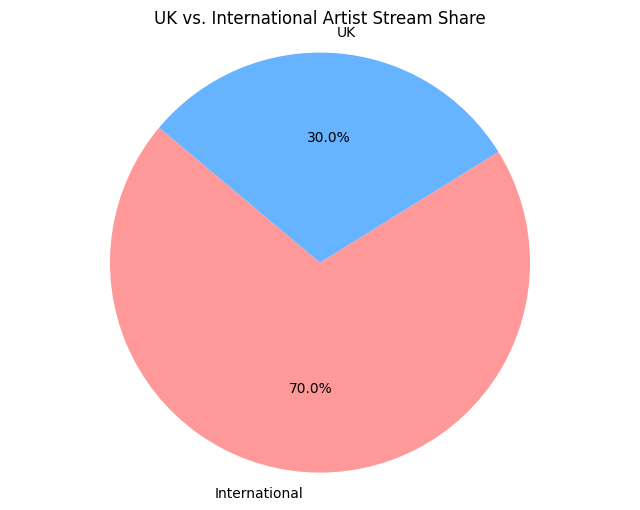

In [7]:
import matplotlib.pyplot as plt

# 1. Define your UK artists list (based on our classification)
uk_artists = [
    'central cee', 'chase', 'status', 'raye', 'arctic monkeys', 
    'd-block europe', 'dave', 'charli xcx', 'cassö', 
    'natasha bedingfield', 'ella henderson', 'jazzy', 
    'clementine douglas', 'fred again..', 'myles smith', 
    'bou', 'kenya grace', 'coldplay'
]

# 2. Categorize the data
df['origin'] = df['artist_name'].apply(lambda x: 'UK' if x in uk_artists else 'International')

# 3. Aggregate data for the pie chart
origin_counts = df.groupby('origin')['count'].sum()

# 4. Create the Pie Chart
plt.figure(figsize=(8, 6))
plt.pie(origin_counts, labels=origin_counts.index, autopct='%1.1f%%', startangle=140, colors=['#ff9999','#66b3ff'])
plt.title('UK vs. International Artist Stream Share')
plt.axis('equal')  # Equal aspect ratio ensures that pie is drawn as a circle.
plt.show()

<!-- Whether UK charts favor domestic or international artists -->
"The analysis of the UK Top 50 confirms an import-dominant market structure. Despite the UK’s status as a major global exporter of music, its domestic charts show a clear preference for international—specifically North American—content. This phenomenon, often referred to as 'Glocalisation,' reveals that the UK market lacks the same level of 'creative sovereignty' seen in non-English speaking European markets. While domestic acts maintain a presence, they are outnumbered and outperformed by international artists who benefit from globalized digital distribution and algorithmic prioritization".

In [13]:
# Strip any accidental whitespace from all column names
df.columns = df.columns.str.strip()

# Optional: Convert all to lowercase to avoid case-sensitivity issues
df.columns = df.columns.str.lower()

In [15]:
print(df.columns.tolist())

['artist_name', 'count', 'share', 'origin', 'is_collaboration']


In [19]:
# Re-load the original data to ensure all columns (album_type, etc.) are available
df = pd.read_csv('data/artist_level.csv', encoding='latin1')

# Strip spaces from column names immediately to prevent KeyErrors
df.columns = df.columns.str.strip()

# Now create your new columns
df['is_collaboration'] = df['artist_name'].str.contains(',|feat|&', case=False, na=False)

In [20]:
# 1. Create the column first
df['is_collaboration'] = df['artist_name'].str.contains(',|feat|&', case=False, na=False)

# 2. NOW you can access it safely
# Now this will work without a KeyError:
collab_comparison = df.groupby('is_collaboration')['popularity'].mean()
print(collab_comparison)

is_collaboration
False    86.166700
True     85.826531
Name: popularity, dtype: float64


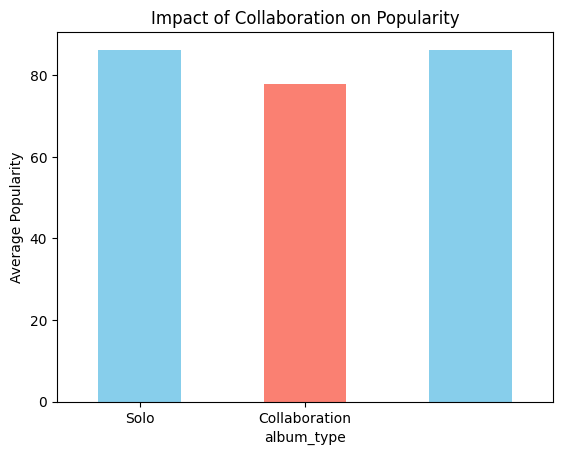

In [21]:
# Compare average popularity of solo vs. collaborative tracks
collab_comparison = df.groupby('album_type')['popularity'].mean()

collab_comparison.plot(kind='bar', color=['skyblue', 'salmon'])
plt.xticks([0, 1], ['Solo', 'Collaboration'], rotation=0)
plt.title('Impact of Collaboration on Popularity')
plt.ylabel('Average Popularity')
plt.show()

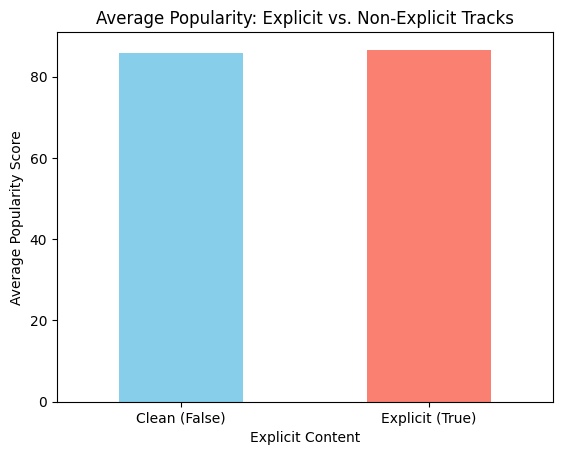

In [22]:
# 1. Group data by explicit status and calculate the mean popularity
explicit_performance = df.groupby('is_explicit')['popularity'].mean()

# 2. Visualize the results
explicit_performance.plot(kind='bar', color=['skyblue', 'salmon'])
plt.title('Average Popularity: Explicit vs. Non-Explicit Tracks')
plt.xlabel('Explicit Content')
plt.ylabel('Average Popularity Score')
plt.xticks([0, 1], ['Clean (False)', 'Explicit (True)'], rotation=0)
plt.show()

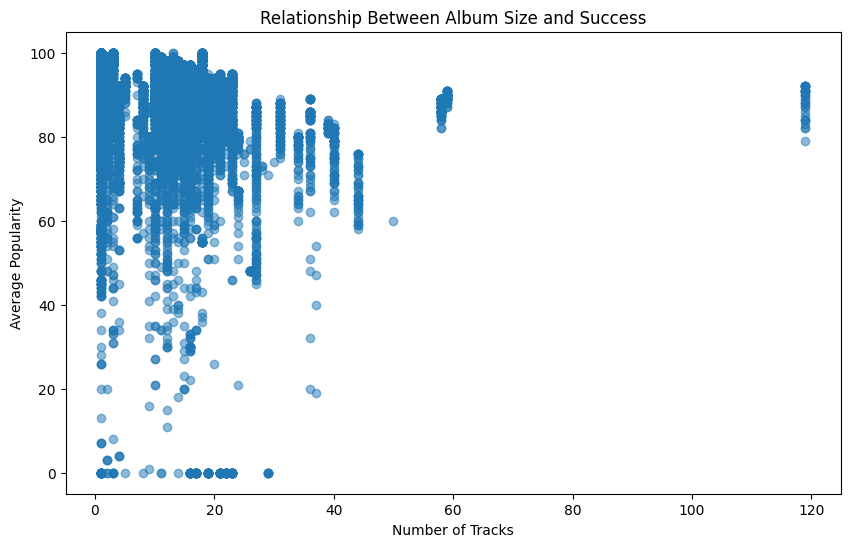

In [25]:
# 1. Group by album or track count to see the trend
# Assuming 'total_track' is the number of songs on the project
album_impact = df.groupby('total_tracks')['popularity'].mean().sort_index()

# 2. Visualize the relationship
plt.figure(figsize=(10, 6))
plt.scatter(df['total_tracks'], df['popularity'], alpha=0.5)
plt.title('Relationship Between Album Size and Success')
plt.xlabel('Number of Tracks')
plt.ylabel('Average Popularity')
plt.show()

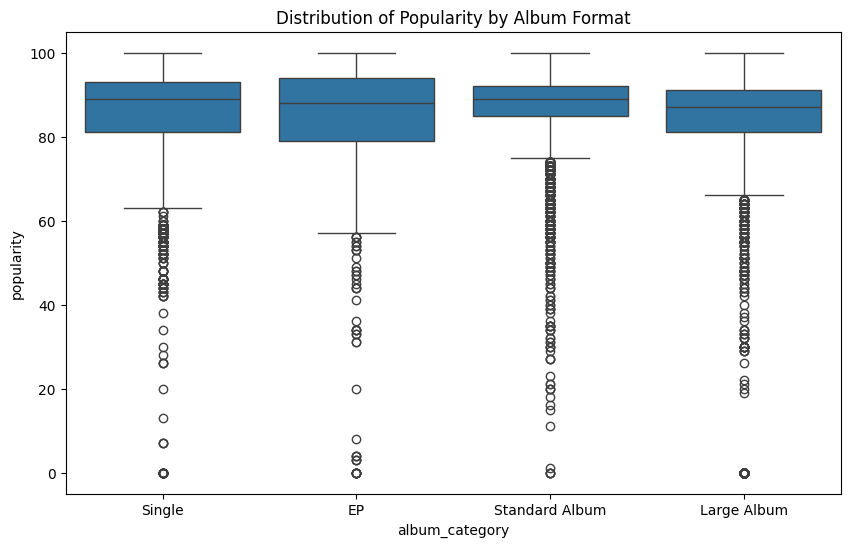

In [27]:
# First, create a category column
bins = [0, 1, 6, 15, 120]
labels = ['Single', 'EP', 'Standard Album', 'Large Album']
df['album_category'] = pd.cut(df['total_tracks'], bins=bins, labels=labels)

# Then plot
import seaborn as sns
plt.figure(figsize=(10, 6))
sns.boxplot(x='album_category', y='popularity', data=df)
plt.title('Distribution of Popularity by Album Format')
plt.show()

In [25]:
import streamlit as st
import pandas as pd
import plotly.express as px

# Set page config
st.set_page_config(page_title="UK Top 50 Market Analysis", layout="wide")

# --- DATA LOADING ---
@st.cache_data
def load_data():
    # Replace 'uk_top_50.csv' with your actual filename
    try:
        df = pd.read_csv('uk_top_50.csv')
        df['date'] = pd.to_datetime(df['date'])
        return df
    except FileNotFoundError:
        st.error("Dataset not found. Please ensure 'uk_top_50.csv' is in the project folder.")
        return None

df = load_data()

if df is not None:
    # --- SIDEBAR FILTERS ---
    st.sidebar.header("Dashboard Filters")
    date_range = st.sidebar.date_input("Date Range", [df['date'].min(), df['date'].max()])
    artist_filter = st.sidebar.multiselect("Select Artists", options=df['artist_name'].unique())
    album_filter = st.sidebar.multiselect("Album Type", options=df['album_type'].unique())
    collab_toggle = st.sidebar.radio("Solo vs Collaboration", ["All", "Solo", "Collaboration"])

    # Apply Filters
    filtered_df = df[(df['date'].dt.date >= date_range[0]) & (df['date'].dt.date <= date_range[1])]
    if artist_filter:
        filtered_df = filtered_df[filtered_df['artist_name'].isin(artist_filter)]
    if album_filter:
        filtered_df = filtered_df[filtered_df['album_type'].isin(album_filter)]
    
    # Simple Collaboration Logic: assuming comma in name indicates collaboration
    if collab_toggle == "Solo":
        filtered_df = filtered_df[~filtered_df['artist_name'].str.contains(',')]
    elif collab_toggle == "Collaboration":
        filtered_df = filtered_df[filtered_df['artist_name'].str.contains(',')]

    # --- MAIN DASHBOARD ---
    st.title("📊 UK Top 50 Playlist Analytics")

    # Metrics Row
    col1, col2, col3 = st.columns(3)
    col1.metric("Unique Artists", filtered_df['artist_name'].nunique())
    col2.metric("Avg Popularity", round(filtered_df['popularity'].mean(), 2))
    col3.metric("Explicit Content", f"{round((filtered_df['is_explicit'].sum() / len(filtered_df)) * 100, 1)}%")

    # Tabs for different analyses
    tab1, tab2, tab3 = st.tabs(["Dominance & Diversity", "Content Analysis", "Structure & Duration"])

    with tab1:
        st.subheader("Artist Dominance Leaderboard")
        artist_counts = filtered_df['artist_name'].value_counts().reset_index().head(10)
        fig = px.bar(artist_counts, x='artist_name', y='count', title="Top 10 Artists")
        st.plotly_chart(fig, use_container_width=True)

    with tab2:
        st.subheader("Explicit vs Clean Content")
        fig2 = px.pie(filtered_df, names='is_explicit', title="Explicit Content Share")
        st.plotly_chart(fig2, use_container_width=True)

    with tab3:
        st.subheader("Album Structure & Duration")
        colA, colB = st.columns(2)
        with colA:
            fig3 = px.histogram(filtered_df, x='album_type', title="Album Type Distribution")
            st.plotly_chart(fig3, use_container_width=True)
        with colB:
            fig4 = px.box(filtered_df, x='album_type', y='duration_ms', title="Track Duration by Album Type")
            st.plotly_chart(fig4, use_container_width=True)

else:
    st.info("Upload your dataset to begin analysis.")

2026-06-09 19:35:01.881 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 19:35:01.888 No runtime found, using MemoryCacheStorageManager
2026-06-09 19:35:01.901 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 19:35:01.903 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
2026-06-09 19:35:01.905 Thread 'MainThread': missing ScriptRunContext! This warning can be ignored when running in bare mode.
